In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

df = pd.read_csv("Employee.csv")

df.info()

for column in df.columns:
    print("\n", column)
    print("Unique values:", df[column].unique())
    print("Length:", df[column].nunique())

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    str    
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    str    
 4   Country  148 non-null    str    
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 7.1 KB

 Company
Unique values: <StringArray>
[                      'TCS',                   'Infosys',
                       'CTS',                         nan,
 'Tata Consultancy Services',                'Congnizant',
           'Infosys Pvt Lmt']
Length: 7, dtype: str
Length: 6

 Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 29

 Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 48

Statistical analysis

In [2]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


Rename columns

In [3]:
df.rename(columns={
    'Company': 'company',
    'Age': 'age',
    'Salary': 'salary',
    'Place': 'place',
    'Country': 'country',
    'Gender': 'gender'
}, inplace=True)

2) DATA CLEANING

Find missing values

In [4]:
df.isnull().sum()


company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64

Replace age o with Nan

In [9]:
df['age'] = df['age'].replace(0, np.nan)

Remove duplicate rows

In [10]:
df = df.drop_duplicates()

Find Outliers

In [11]:
Q1 = df[['age', 'salary']].quantile(0.25)
Q3 = df[['age', 'salary']].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    ((df[['age', 'salary']] < lower) |
     (df[['age', 'salary']] > upper)).any(axis=1)
]

print(outliers)

Empty DataFrame
Columns: [company, age, salary, place, country, gender]
Index: []


Treat null values

In [12]:
df['age'] = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df['salary'].median())

df['company'] = df['company'].fillna(df['company'].mode()[0])
df['place'] = df['place'].fillna(df['place'].mode()[0])
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

3)DATA ANALYSIS

In [13]:
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]

print(filtered_df)

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


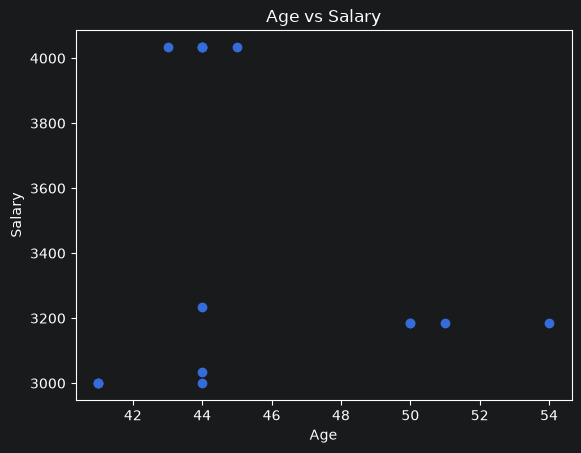

In [14]:
plt.scatter(filtered_df['age'], filtered_df['salary'])

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()

In [15]:
place_count = df['place'].value_counts()

print(place_count)

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


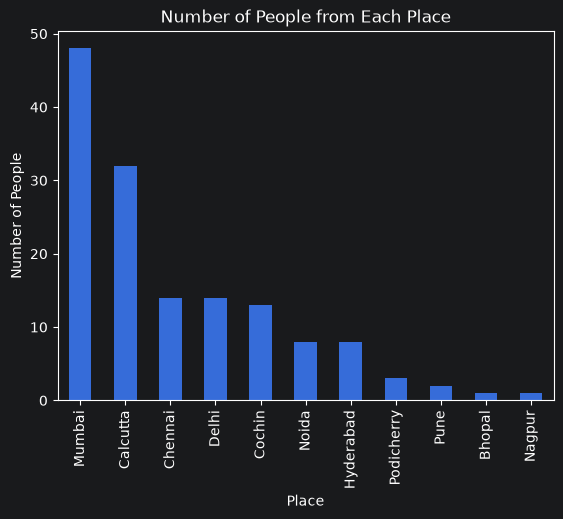

In [16]:
place_count.plot(kind='bar')

plt.xlabel("Place")
plt.ylabel("Number of People")
plt.title("Number of People from Each Place")

plt.show()

4)DATA ENCODING

In [17]:
le = LabelEncoder()

df['company'] = le.fit_transform(df['company'])

In [18]:
df = pd.get_dummies(df, columns=['place'], dtype=int)

5)FEATURE SCALING

Standardscaler

In [19]:
scaler = StandardScaler()

df[['age', 'salary']] = scaler.fit_transform(
    df[['age', 'salary']]
)

Minmaxscaler

In [20]:
scaler = MinMaxScaler()

df[['age', 'salary']] = scaler.fit_transform(
    df[['age', 'salary']]
)